# Exploratory Data Analysis

**Target:** `TARGET` (1 = client with payment difficulties, 0 = repaid). 


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/raw/application_train.csv")
df.shape

(307511, 122)

## 1. Shape & structure

Before any cleaning, I map each column to its *measurement scale* rather than trusting its pandas dtype — the two don't align here. Several `int64`/`float64` columns are actually binary flags (`FLAG_*`) or ordinal ratings (`REGION_RATING_CLIENT`), not continuous quantities. That distinction, not the storage type, decides what later gets scaled versus encoded.

In [2]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Takeaway:** the 122 columns fall into four scales — continuous (`AMT_*`, `DAYS_*`, `EXT_SOURCE_*`), binary flags (`FLAG_*`), 16 nominal text categoricals, and a ~47-column block of collinear building statistics (`_AVG`/`_MEDI`/`_MODE` triplets). Preprocessing therefore needs a `ColumnTransformer` with distinct branches: scale the continuous columns, one-hot the categoricals, pass the flags through untouched.

## 2. Missing values

Missingness is the first filter on the feature set — mostly-empty columns carry little signal and complicate imputation. I rank every column by missing rate to decide what to drop, but rate alone isn't a sufficient criterion: some gaps are *structural* (a field that simply doesn't apply to certain clients), and some sit on columns that could still turn out to be predictive despite the missingness. Columns flagged by the threshold get a closer look before being cut, not an automatic drop.

In [ ]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
THRESHOLD = 50
cols_above = missing_pct[missing_pct > THRESHOLD]
print(f"{len(cols_above)} columns above {THRESHOLD}% missing")
cols_above.head(15)

41 columns above 50% missing


COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
dtype: float64

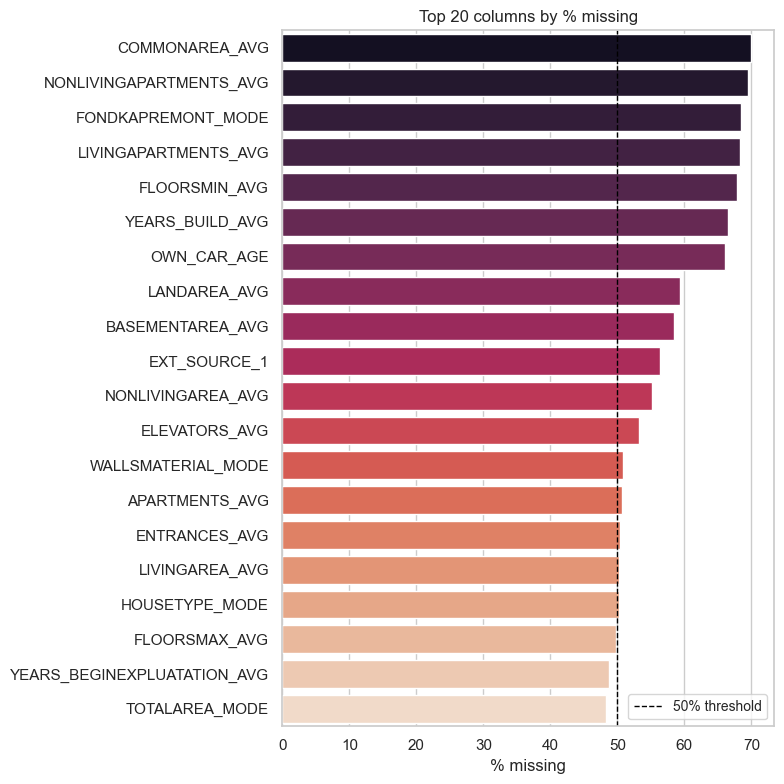

In [ ]:
# The building _AVG/_MEDI/_MODE variants share identical missingness; collapse to the _AVG representative 
# for a readable plot (keeping metrics that exist only as _MODE).
avg_bases = {c[:-4] for c in missing_pct.index if c.endswith("_AVG")}
redundant = [c for c in missing_pct.index
             if (c.endswith("_MEDI") or c.endswith("_MODE")) and c[:-5] in avg_bases]
missing_pct_plot = missing_pct.drop(redundant)

top = missing_pct_plot.head(20)
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette="rocket", legend=False, ax=ax)
ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"{THRESHOLD}% threshold")
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Top 20 columns by % missing")
ax.legend(loc="lower right", fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/missing_values_top20.png", dpi=150)
plt.show()

### Structural missingness

`OWN_CAR_AGE` is 66% missing, but the gap looks structural rather than random — a car's age is undefined for clients who own no car. If that's the cause, the missingness should line up exactly with `FLAG_OWN_CAR = 'N'`:

In [9]:
pd.crosstab(df["FLAG_OWN_CAR"], df["OWN_CAR_AGE"].isna(),
            rownames=["FLAG_OWN_CAR"], colnames=["OWN_CAR_AGE missing"])

OWN_CAR_AGE missing,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


**Takeaway:** 41 columns exceed 50% missingness — but that headline count is inflated by redundancy: they collapse to just **17 distinct features**, since 12 building metrics are each counted three times as `_AVG`/`_MEDI`/`_MODE` variants of the same measurement. Two columns stand apart from that block: `OWN_CAR_AGE` (66% missing, but *structurally* — blank exactly when the client owns no car, per the crosstab above) and `EXT_SOURCE_1` (56% missing, but a normalized external score — a pre-built summary signal from outside the application, worth carrying forward for inspection rather than dropping on missingness alone). Missingness rate alone is therefore a misleading filter here — most "high-missing" columns are duplicates of one another, and the rest deserve a closer look before any are dropped.